# Which recorded value is the *true* label? An executable proof for every parameter

Our grids record each parameter twice: the **requested** value (`teff`, `logg`, `feh`, `vmicro`, `a`, ...) and the **MARCS atmosphere's** value (`marcs_teff`, `marcs_logg`, `marcs_fe_h`, `marcs_turb`, `marcs_a_fe`). This notebook determines, by direct synthesis, which of the two the spectrum actually responds to — parameter by parameter.

**Mechanism.** Turbospectrum's inputs are the atmosphere file (`MODELINPUT`), plus `METALLICITY`, `ALPHA/Fe`, individual abundances, and `XIFIX` vmicro. Requested **teff and logg appear nowhere** — they act only by selecting the atmosphere file via the nearest-model snap. Requested **feh, vmicro, and abundances are passed directly** to babsma/bsyn regardless of which atmosphere was snapped.

**Predictions**, tested below with real syntheses (LTE, 5000–5020 Å, ~2 min total):

| Experiment | Vary | Same snapped atmosphere? | Predicted spectra |
|---|---|---|---|
| 1 | teff 4900 → 5200 | 4900/5000/5100 yes; 5200 no | identical within the snap cell, control differs |
| 2 | logg 3.9 → 4.4 | 3.9–4.2 yes; 4.3–4.4 second cell | identical within each cell |
| 3 | feh −0.1 → +0.1 | yes (all z+0.00) | **different** — METALLICITY is applied |
| 4 | vmicro 0.8 → 1.2 | yes (all t01) | **different** — XIFIX is applied |
| 5 | [α/Fe] 0.0 vs +0.3 | yes (all a+0.00) | **different** — abundances are applied |

Requirements: built `exec-gf` binaries, the GES linelist, the MARCS store (same setup as any local smoke run).

In [1]:
import json
import os
import subprocess
import sys
from types import SimpleNamespace

import numpy as np

sys.path.insert(0, os.path.join(os.getcwd(), "scripts"))
from zarr_compat import open_root_group

BASE_ROOT = os.path.abspath("runs/snap-semantics-demo")  # absolute: a relative run_root resolves against the config dir
FORCE_RERUN = False

_FIXED_ABUND = {k: "+0.00" for k in ("a", "c", "n", "o", "r", "s")}

def _store_is_usable(path):
    if not os.path.exists(path):
        return False
    names = [str(n) for n in open_root_group(path, mode="r")["param_names"][...]]
    return "marcs_teff" in names  # skipped-row stores lack the marcs_* columns

def run_experiment(name, axes, abundances=None):
    """Run one tiny synthesis grid and return its params/flux/wavelength."""
    run_root = os.path.join(BASE_ROOT, name)
    store = os.path.join(run_root, "outputs", "zarr", "synthesized_spectra.zarr")
    if FORCE_RERUN or not _store_is_usable(store):
        cfg = {
            "grid": {
                "grid_version": f"snap-semantics-{name}-v1",
                "sampling": "grid",
                "axes": axes,
                "abundances": {**_FIXED_ABUND, **(abundances or {})},
                "synthesis": {"lam_min": 5000.0, "lam_max": 5020.0, "lam_step": 0.01, "output_mode": "Flux"},
                "mode": "1D",
                "calculation_mode": "LTE",
                "io": {"csv_compression": "zstd", "csv_compression_level": 5, "zarr_chunks": 4096,
                       "zarr_compressor": {"cname": "zstd", "clevel": 5, "shuffle": True}},
            },
            "turbospectrum": {
                "compiler": "gf",
                # force=True: stale .spec files with matching stems would be
                # "skipped", and skipped rows carry no marcs_* columns.
                "force": True,
                "max_workers": None,
                "executables": {"babsma_exec": "babsma_lu", "bsyn_exec": "bsyn_lu", "interpol_exec": "interpol_modeles"},
                "paths": {"model_atmosphere_path": "", "linelist_path": "input_files/linelists",
                          "linelist_files": ["nlte_ges_linelist_jmg16jan2026_I_II"], "model_opac_dir": "COM/contopac"},
                "synthesis_parameters": {"output_mode": "Flux", "resolution": 115000.0},
                "nlte": {"enabled": False, "nlte_info_file": ""},
                "provenance": {"environment_capture": "none"},
            },
            "outputs": {"run_root": run_root},
            "runtime": {"workers": 2, "scratch": None, "chunk_rows": 64},
        }
        os.makedirs(run_root, exist_ok=True)
        cfg_path = os.path.join(run_root, "config.json")
        with open(cfg_path, "w", encoding="utf-8") as fh:
            json.dump(cfg, fh, indent=2)
        proc = subprocess.run([sys.executable, "scripts/pipeline_from_config.py", "--config", cfg_path],
                              capture_output=True, text=True)
        if proc.returncode != 0:
            print(proc.stdout[-800:]); print(proc.stderr[-2000:])
            raise RuntimeError(f"pipeline run '{name}' failed")
    g = open_root_group(store, mode="r")
    names = [str(n) for n in g["param_names"][...]]
    params = np.asarray(g["params"][...], dtype=float)
    exp = SimpleNamespace(
        name=name,
        cols={c: params[:, i] for i, c in enumerate(names)},
        flux=np.asarray(g["flux"][...], dtype=np.float64),
        wl=np.asarray(g["wavelength"][...], dtype=np.float64),
        n=params.shape[0],
    )
    print(f"{name}: {exp.n} spectra ready")
    return exp

BASE_AXES = {"teff": "5000", "logg": "4.0", "feh": "0.0", "turbvel": "01"}

exp_teff = run_experiment("teff", {**BASE_AXES, "teff": "4900:5200:100"})
exp_logg = run_experiment("logg", {**BASE_AXES, "logg": "3.9:4.4:0.1"})
exp_feh = run_experiment("feh", {**BASE_AXES, "feh": "-0.1:0.1:0.1"})
exp_vmic = run_experiment("vmicro", {"teff": "5000", "logg": "4.0", "feh": "0.0",
                                     "vmicro": "0.8:1.2:0.2",
                                     "t_value_options": ["00", "01", "02", "05"]})
exp_alpha = run_experiment("alpha", BASE_AXES, abundances={"a": "0.0:0.3:0.3"})

teff: 4 spectra ready
logg: 6 spectra ready
feh: 3 spectra ready
vmicro: 3 spectra ready
alpha: 2 spectra ready


## Verdicts

Each experiment below prints its snap table and asserts its prediction — the notebook fails loudly if any of them stops holding.

In [2]:
def rows_by(exp, col):
    return {round(float(v), 4): r for r, v in enumerate(exp.cols[col])}

def max_rel_diff(exp, r_a, r_b):
    return float(np.max(np.abs(exp.flux[r_a] - exp.flux[r_b]) / np.maximum(np.abs(exp.flux[r_b]), 1e-30)))

summary = {}  # parameter -> (max within-atmosphere-cell rel diff, class)

# --- 1. teff: atmosphere-only ------------------------------------------------
rt = rows_by(exp_teff, "teff")
for t in (4900, 5100):
    assert np.array_equal(exp_teff.flux[rt[t]], exp_teff.flux[rt[5000]]), f"teff {t} vs 5000 differ!"
assert not np.array_equal(exp_teff.flux[rt[5200]], exp_teff.flux[rt[5000]])
summary["teff"] = (0.0, "atmosphere-only")
print(f"teff  : 4900/5000/5100 (marcs 5000) bit-identical; 5200 (marcs 5250) differs by {max_rel_diff(exp_teff, rt[5200], rt[5000]):.0%}")

# --- 2. logg: atmosphere-only ------------------------------------------------
rl = rows_by(exp_logg, "logg")
groups = {}
for g_val, r in rl.items():
    groups.setdefault(float(exp_logg.cols["marcs_logg"][r]), []).append((g_val, r))
for m_logg, members in sorted(groups.items()):
    ref = members[0][1]
    for _, r in members[1:]:
        assert np.array_equal(exp_logg.flux[r], exp_logg.flux[ref]), f"logg group {m_logg} not identical!"
    print(f"logg  : requested {sorted(v for v, _ in members)} -> marcs_logg {m_logg}: bit-identical within cell")
cells_sorted = sorted(groups.items())
assert not np.array_equal(exp_logg.flux[cells_sorted[0][1][0][1]], exp_logg.flux[cells_sorted[1][1][0][1]])
summary["logg"] = (0.0, "atmosphere-only")

# --- 3/4/5. feh, vmicro, alpha: synthesis-applied ----------------------------
for exp, col, marcs_col, ref_val, label in (
    (exp_feh, "feh", "marcs_fe_h", 0.0, "feh"),
    (exp_vmic, "vmicro", "marcs_turb", 1.0, "vmicro"),
    (exp_alpha, "a", "marcs_a_fe", 0.0, "alpha [a/Fe]"),
):
    rr = rows_by(exp, col)
    marcs_vals = np.unique(exp.cols[marcs_col])
    assert len(marcs_vals) == 1, f"{label}: atmosphere not held fixed! {marcs_vals}"
    ref = rr[ref_val]
    worst = 0.0
    for v, r in sorted(rr.items()):
        if r == ref:
            continue
        assert not np.array_equal(exp.flux[r], exp.flux[ref]), f"{label} {v} vs {ref_val}: unexpectedly identical!"
        worst = max(worst, max_rel_diff(exp, r, ref))
    summary[label] = (worst, "synthesis-applied")
    print(f"{label:6s}: all rows share ONE atmosphere ({marcs_col} = {marcs_vals[0]:g}) "
          f"yet spectra differ — max rel diff {worst:.1%}")

teff  : 4900/5000/5100 (marcs 5000) bit-identical; 5200 (marcs 5250) differs by 122%
logg  : requested [3.9, 4.0, 4.1, 4.2] -> marcs_logg 4.0: bit-identical within cell
logg  : requested [4.3, 4.4] -> marcs_logg 4.5: bit-identical within cell
feh   : all rows share ONE atmosphere (marcs_fe_h = 0) yet spectra differ — max rel diff 15.7%
vmicro: all rows share ONE atmosphere (marcs_turb = 1) yet spectra differ — max rel diff 34.0%
alpha [a/Fe]: all rows share ONE atmosphere (marcs_a_fe = 0) yet spectra differ — max rel diff 32.7%


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt

SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["system-ui", "-apple-system", "Segoe UI", "Helvetica Neue", "Arial", "sans-serif"],
    "text.color": INK, "axes.labelcolor": INK_2,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.titlecolor": INK, "axes.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
})

### Atmosphere-only: three requested teffs, one spectrum

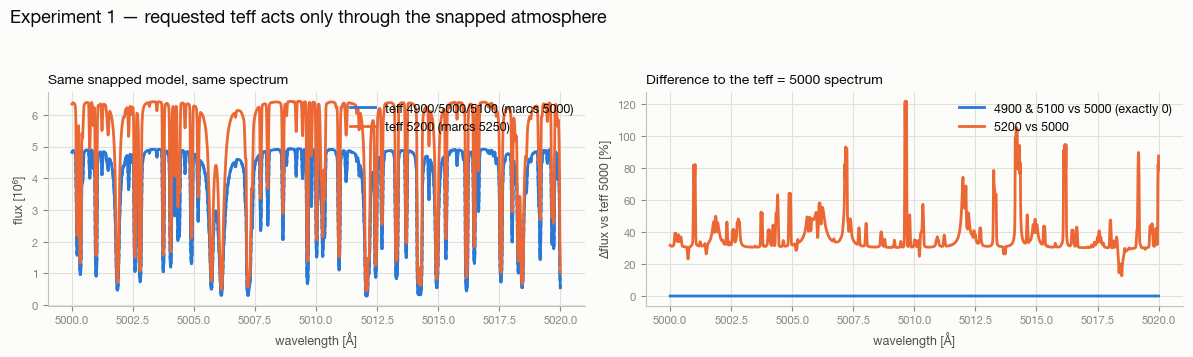

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.6))

for t, style in ((4900, "-"), (5000, "--"), (5100, ":")):
    ax1.plot(exp_teff.wl, exp_teff.flux[rt[t]] / 1e6, style, color=BLUE, linewidth=2,
             label="teff 4900/5000/5100 (marcs 5000)" if t == 4900 else None)
ax1.plot(exp_teff.wl, exp_teff.flux[rt[5200]] / 1e6, color=ORANGE, linewidth=2,
         label="teff 5200 (marcs 5250)")
ax1.set_xlabel("wavelength [Å]"); ax1.set_ylabel("flux [10⁶]")
ax1.set_title("Same snapped model, same spectrum", loc="left")
ax1.legend(loc="upper right")

ax2.plot(exp_teff.wl, np.zeros_like(exp_teff.wl), color=BLUE, linewidth=2,
         label="4900 & 5100 vs 5000 (exactly 0)")
ax2.plot(exp_teff.wl, 100 * (exp_teff.flux[rt[5200]] - exp_teff.flux[rt[5000]]) / exp_teff.flux[rt[5000]],
         color=ORANGE, linewidth=2, label="5200 vs 5000")
ax2.set_xlabel("wavelength [Å]"); ax2.set_ylabel("Δflux vs teff 5000 [%]")
ax2.set_title("Difference to the teff = 5000 spectrum", loc="left")
ax2.legend(loc="upper right")

fig.suptitle("Experiment 1 — requested teff acts only through the snapped atmosphere",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

### Synthesis-applied: one atmosphere, three different spectra

Every curve below compares against the middle value of its experiment, **with the snapped atmosphere held identical** — the differences are pure synthesis-input effects.

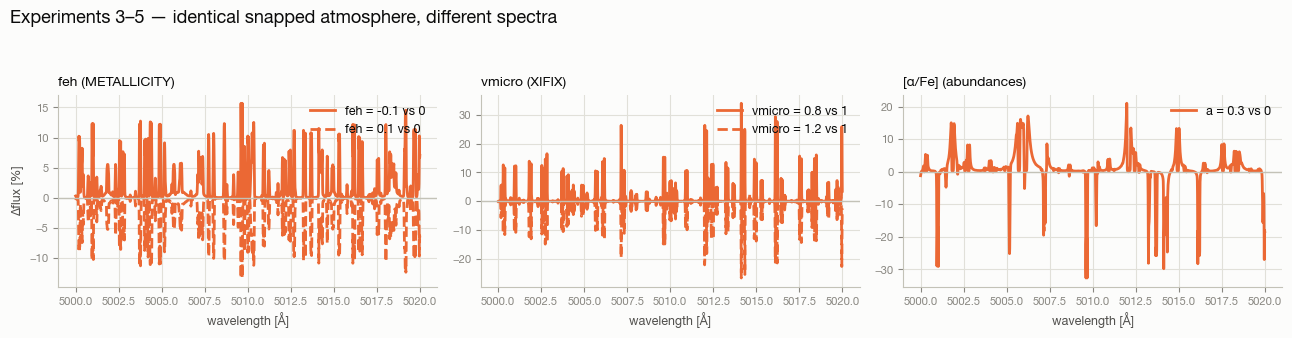

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
PANELS = (
    (axes[0], exp_feh, "feh", 0.0, "feh (METALLICITY)"),
    (axes[1], exp_vmic, "vmicro", 1.0, "vmicro (XIFIX)"),
    (axes[2], exp_alpha, "a", 0.0, "[α/Fe] (abundances)"),
)
for ax, exp, col, ref_val, title in PANELS:
    rr = rows_by(exp, col)
    ref = rr[ref_val]
    others = [v for v in sorted(rr) if rr[v] != ref]
    for v, style in zip(others, ("-", "--")):
        ax.plot(exp.wl, 100 * (exp.flux[rr[v]] - exp.flux[ref]) / exp.flux[ref],
                style, color=ORANGE, linewidth=2, label=f"{col} = {v:g} vs {ref_val:g}")
    ax.axhline(0, color=BASELINE, linewidth=1)
    ax.set_xlabel("wavelength [Å]")
    ax.set_ylabel("Δflux [%]" if ax is axes[0] else "")
    ax.set_title(title, loc="left")
    ax.legend(loc="upper right")
fig.suptitle("Experiments 3–5 — identical snapped atmosphere, different spectra",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

### Summary — maximum flux change while holding the snapped atmosphere fixed

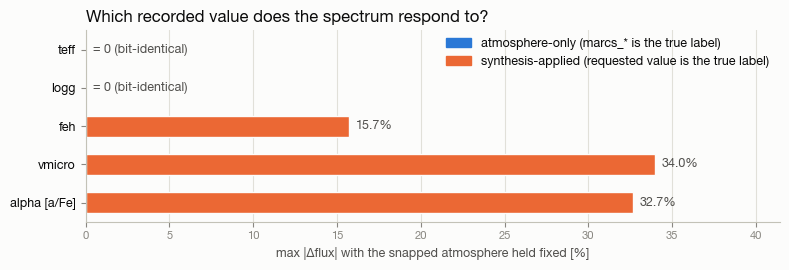

In [6]:
order = ["teff", "logg", "feh", "vmicro", "alpha [a/Fe]"]
vals = [summary[k][0] * 100 for k in order]
kinds = [summary[k][1] for k in order]

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.grid(axis="y", visible=False)
ypos = np.arange(len(order))[::-1]
colors = [BLUE if k == "atmosphere-only" else ORANGE for k in kinds]
ax.barh(ypos, [max(v, 0) for v in vals], height=0.55, color=colors, edgecolor=SURFACE, linewidth=1)
for y, v in zip(ypos, vals):
    ax.annotate("= 0 (bit-identical)" if v == 0 else f"{v:.1f}%",
                xy=(v, y), xytext=(5, 0), textcoords="offset points", va="center",
                color=INK_2, fontsize=9)
ax.set_yticks(ypos, order)
ax.tick_params(axis="y", labelsize=9, labelcolor=INK)
ax.set_xlabel("max |Δflux| with the snapped atmosphere held fixed [%]")
ax.set_xlim(0, max(vals) * 1.22)
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=ORANGE)]
ax.legend(handles, ["atmosphere-only (marcs_* is the true label)",
                    "synthesis-applied (requested value is the true label)"],
          loc="upper right", bbox_to_anchor=(1.0, 1.02))
ax.set_title("Which recorded value does the spectrum respond to?", loc="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

## Conclusion — the label semantics of every recorded pair

| Parameter | Reaches Turbospectrum? | Within-cell flux change | True label for training |
|---|---|---|---|
| teff | No — atmosphere-file choice only | exactly 0 (bit-identical) | **`marcs_teff`** |
| logg | No — atmosphere-file choice only | exactly 0 (bit-identical) | **`marcs_logg`** |
| [Fe/H] | Yes (`METALLICITY`) | percent-level line changes | **requested `feh`** (`marcs_fe_h` = second-order structure effect) |
| vmicro | Yes (`XIFIX`) | percent-level line changes | **requested `vmicro`** (`marcs_turb` = structure only) |
| [α/Fe] & abundances | Yes (`ALPHA/Fe` + abundance block) | percent-level changes | **requested values** (`marcs_a_fe` etc. = structure only) |

Practical consequences:

- **Train emulators on `marcs_teff` and `marcs_logg`**, never on the requested values — within a snap cell (±125 K, ±0.25 dex) the requested value carries zero spectral information, so using it as a label injects pure noise.
- **Requested `feh`, `vmicro`, and abundances are the primary labels** for their parameters; the `marcs_*` structure columns are useful auxiliary features that capture the (second-order) atmosphere-structure mismatch.
- The `marcs_c_fe` / `marcs_n_fe` / `marcs_o_fe` columns are composition bookkeeping of the standard MARCS grid (c = n = 0, o follows alpha) — same synthesis-applied logic applies to the requested `c`, `n`, `o` values.